In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import os

BASE      = r"E:\PROJECTS\mutual-fund-dashboard"
PROCESSED = os.path.join(BASE, "data", "processed")
RAW       = os.path.join(BASE, "data", "raw")
CHARTS    = os.path.join(BASE, "reports", "charts")
OUTPUT    = os.path.join(BASE, "data", "processed")
os.makedirs(CHARTS, exist_ok=True)

# Load datasets
fund_master = pd.read_csv(f"{PROCESSED}/01_fund_master_clean.csv")
benchmark   = pd.read_csv(f"{PROCESSED}/10_benchmark_indices_clean.csv")
performance = pd.read_csv(f"{PROCESSED}/07_scheme_performance_clean.csv")

# Load nav_history from raw to keep amfi_code
nav = pd.read_csv(f"{RAW}/02_nav_history.csv")
nav.columns = nav.columns.str.strip().str.lower().str.replace(" ", "_")
nav["date"] = pd.to_datetime(nav["date"], dayfirst=True, errors="coerce")
nav = nav[nav["nav"] > 0].drop_duplicates(subset=["amfi_code", "date"])
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Parse benchmark dates
benchmark["date"] = pd.to_datetime(benchmark["date"], errors="coerce")
benchmark = benchmark.sort_values("date").reset_index(drop=True)

print("✅ Data loaded")
print("NAV shape:", nav.shape)
print("Funds:", nav["amfi_code"].nunique())
print("Benchmark indices:", benchmark.columns.tolist())
print(benchmark.head(2))

✅ Data loaded
NAV shape: (46000, 3)
Funds: 40
Benchmark indices: ['date', 'index_name', 'close_value']
        date     index_name  close_value
0 2022-01-03        NIFTY50     17492.79
1 2022-01-03  CRISIL_LIQUID      2281.51


Daily returns shape: (1149, 40)

Mean daily return per fund (first 5):
amfi_code
100016    0.000142
100025    0.000170
100033    0.001080
101206    0.000852
101207    0.000424
dtype: float64

Std of daily returns (first 5):
amfi_code
100016    0.009164
100025    0.002460
100033    0.011929
101206    0.009177
101207    0.016251
dtype: float64


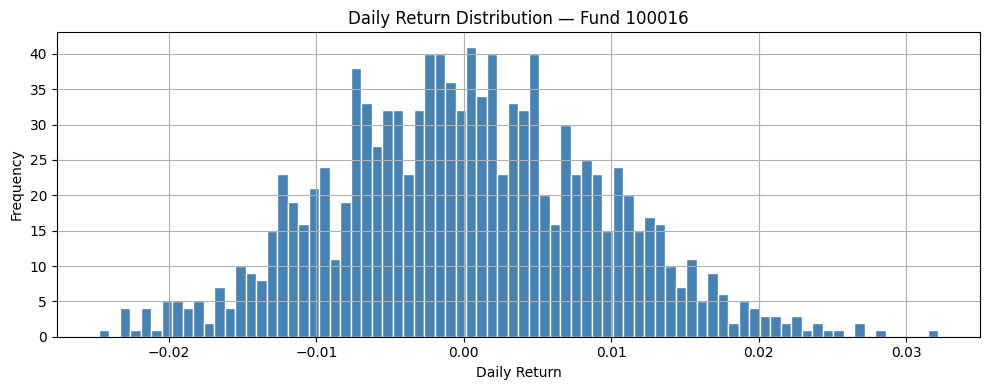

✅ Daily returns computed


In [2]:
# Pivot NAV to wide format — one column per fund
nav_pivot = nav.pivot(index="date", columns="amfi_code", values="nav")

# Daily returns: (nav_t / nav_t-1) - 1
daily_returns = nav_pivot.pct_change().dropna(how="all")

# Validate distribution
print("Daily returns shape:", daily_returns.shape)
print("\nMean daily return per fund (first 5):")
print(daily_returns.mean().head())
print("\nStd of daily returns (first 5):")
print(daily_returns.std().head())

# Plot distribution of daily returns for one fund
sample_fund = daily_returns.columns[0]
plt.figure(figsize=(10, 4))
daily_returns[sample_fund].hist(bins=80, color="steelblue", edgecolor="white")
plt.title(f"Daily Return Distribution — Fund {sample_fund}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{CHARTS}/10_daily_return_dist.png", dpi=150)
plt.show()
print("✅ Daily returns computed")

In [3]:
def compute_cagr(nav_series, years):
    """Annualised return using trading-day scaling.

    Uses the actual number of trading days in the series and annualises
    with 252 trading days per year: (NAV_end / NAV_start)^(252/N) - 1
    """
    series = nav_series.dropna()
    if len(series) < 2:
        return np.nan
    nav_end = series.iloc[-1]
    nav_start = series.iloc[0]
    if nav_start <= 0:
        return np.nan
    n_trading_days = len(series)
    return (nav_end / nav_start) ** (252.0 / n_trading_days) - 1

cagr_records = []

for amfi_code in nav["amfi_code"].unique():
    fund_nav = nav[nav["amfi_code"] == amfi_code].set_index("date")["nav"].sort_index()
    end_date = fund_nav.index.max()

    record = {"amfi_code": amfi_code}

    for label, years in [("cagr_1yr", 1), ("cagr_3yr", 3), ("cagr_5yr", 5)]:
        start_date = end_date - pd.DateOffset(years=years)
        series = fund_nav[fund_nav.index >= start_date]
        record[label] = round(compute_cagr(series, years) * 100, 2) if len(series) > 5 else np.nan

    cagr_records.append(record)

cagr_df = pd.DataFrame(cagr_records)
cagr_df = cagr_df.merge(fund_master[["amfi_code","scheme_name","fund_house","category"]], on="amfi_code")

print("✅ CAGR computed")
print(cagr_df[["scheme_name","cagr_1yr","cagr_3yr","cagr_5yr"]].sort_values("cagr_3yr", ascending=False).head(10))

✅ CAGR computed
                                          scheme_name  cagr_1yr  cagr_3yr  \
16                Axis Midcap Fund - Regular - Growth     21.33     33.62   
34      Mirae Asset Large Cap Fund - Regular - Growth     19.51     32.56   
24          ICICI Pru Bluechip Fund - Direct - Growth     12.54     31.12   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     50.76     31.07   
25           ICICI Pru Midcap Fund - Regular - Growth     28.33     30.44   
19          SBI Bluechip Fund - Regular Plan - Growth     57.57     29.18   
30             Kotak Flexicap Fund - Regular - Growth     25.52     28.35   
36      Mirae Asset Tax Saver Fund - Regular - Growth     37.98     27.96   
3       ABSL Frontline Equity Fund - Regular - Growth     45.73     27.76   
39              DSP Small Cap Fund - Regular - Growth     62.01     25.88   

    cagr_5yr  
16     27.08  
34     29.71  
24     22.37  
2      28.90  
25     31.48  
19     24.77  
30     29.65  
36     30.64  
3

In [4]:
RF_ANNUAL = 0.065          # RBI repo rate proxy 6.5%
RF_DAILY  = RF_ANNUAL / 252

sharpe_records = []

for amfi_code in daily_returns.columns:
    ret = daily_returns[amfi_code].dropna()
    if len(ret) < 30:
        continue
    excess_ret   = ret - RF_DAILY
    sharpe_ratio = (excess_ret.mean() / ret.std()) * np.sqrt(252)
    sharpe_records.append({
        "amfi_code":    amfi_code,
        "sharpe_ratio": round(sharpe_ratio, 4)
    })

sharpe_df = pd.DataFrame(sharpe_records)
sharpe_df = sharpe_df.merge(fund_master[["amfi_code","scheme_name"]], on="amfi_code")
sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
sharpe_df["sharpe_rank"] = sharpe_df["sharpe_ratio"].rank(ascending=False)

print("✅ Sharpe Ratio computed")
print(sharpe_df[["scheme_name","sharpe_ratio"]].head(10))

✅ Sharpe Ratio computed
                                         scheme_name  sharpe_ratio
0      Mirae Asset Large Cap Fund - Regular - Growth        1.4483
1             Kotak Flexicap Fund - Regular - Growth        1.3067
2      Mirae Asset Tax Saver Fund - Regular - Growth        1.2349
3          SBI Bluechip Fund - Regular Plan - Growth        1.2083
4           ICICI Pru Midcap Fund - Regular - Growth        1.1801
5                 DSP Midcap Fund - Regular - Growth        1.1321
6  HDFC Mid-Cap Opportunities Fund - Regular - Gr...        1.0937
7     Nippon India Large Cap Fund - Regular - Growth        1.0817
8      ABSL Frontline Equity Fund - Regular - Growth        1.0272
9          ICICI Pru Bluechip Fund - Direct - Growth        1.0265


In [5]:
sortino_records = []

for amfi_code in daily_returns.columns:
    ret = daily_returns[amfi_code].dropna()
    if len(ret) < 30:
        continue
    excess_ret    = ret - RF_DAILY
    downside_ret  = ret[ret < 0]
    downside_std  = downside_ret.std() if len(downside_ret) > 1 else np.nan
    if pd.isna(downside_std) or downside_std == 0:
        continue
    sortino_ratio = (excess_ret.mean() / downside_std) * np.sqrt(252)
    sortino_records.append({
        "amfi_code":     amfi_code,
        "sortino_ratio": round(sortino_ratio, 4)
    })

sortino_df = pd.DataFrame(sortino_records)
sortino_df = sortino_df.merge(fund_master[["amfi_code","scheme_name"]], on="amfi_code")
sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False).reset_index(drop=True)
sortino_df["sortino_rank"] = sortino_df["sortino_ratio"].rank(ascending=False)

print("✅ Sortino Ratio computed")
print(sortino_df[["scheme_name","sortino_ratio"]].head(10))

✅ Sortino Ratio computed
                                         scheme_name  sortino_ratio
0      Mirae Asset Large Cap Fund - Regular - Growth         2.3856
1             Kotak Flexicap Fund - Regular - Growth         2.3643
2      Mirae Asset Tax Saver Fund - Regular - Growth         2.1469
3          SBI Bluechip Fund - Regular Plan - Growth         2.1403
4           ICICI Pru Midcap Fund - Regular - Growth         2.0294
5                 DSP Midcap Fund - Regular - Growth         1.8751
6     Nippon India Large Cap Fund - Regular - Growth         1.8501
7  HDFC Mid-Cap Opportunities Fund - Regular - Gr...         1.8291
8          ICICI Pru Bluechip Fund - Direct - Growth         1.8053
9      ABSL Frontline Equity Fund - Regular - Growth         1.7996


In [6]:
# Get Nifty 100 benchmark returns
print("Benchmark columns:", benchmark.columns.tolist())
print(benchmark["index_name"].unique() if "index_name" in benchmark.columns else "check column name")

Benchmark columns: ['date', 'index_name', 'close_value']
<StringArray>
[        'NIFTY50',   'CRISIL_LIQUID', 'NIFTY_MIDCAP150',     'CRISIL_GILT',
        'NIFTY100',        'NIFTY500',    'BSE_SMALLCAP']
Length: 7, dtype: str


In [7]:
if 'alpha_beta_df' in globals():
    print("Funds processed:", len(alpha_beta_df))
else:
    print("Funds processed: alpha_beta_df not defined — run Alpha & Beta cell first")

Funds processed: alpha_beta_df not defined — run Alpha & Beta cell first


In [8]:
# ==========================
# Alpha & Beta Calculation
# ==========================

# Get NIFTY100 benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Convert date column
nifty100["date"] = pd.to_datetime(nifty100["date"])

# Remove duplicate dates if any
nifty100 = (
    nifty100
    .sort_values("date")
    .drop_duplicates(subset=["date"], keep="first")
)

# Create benchmark return series
nifty100 = (
    nifty100
    .set_index("date")["close_value"]
    .sort_index()
)

nifty100_returns = nifty100.pct_change().dropna()

print("Benchmark rows:", len(nifty100))
print("Benchmark return rows:", len(nifty100_returns))
print("Benchmark duplicate dates:",
      nifty100_returns.index.duplicated().sum())

# Ensure daily_returns index is datetime
daily_returns.index = pd.to_datetime(daily_returns.index)

alpha_beta_records = []

for amfi_code in daily_returns.columns:

    fund_ret = daily_returns[amfi_code].dropna()

    # Align benchmark and fund returns
    aligned = pd.concat(
        [fund_ret, nifty100_returns],
        axis=1,
        join="inner"
    ).dropna()

    aligned.columns = ["fund", "benchmark"]

    # Skip if insufficient overlap
    if len(aligned) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        aligned["benchmark"],
        aligned["fund"]
    )

    alpha_beta_records.append({
        "amfi_code": int(amfi_code),
        "beta": round(slope, 4),
        "alpha": round(intercept * 252 * 100, 4),
        "r_squared": round(r_value**2, 4)
    })

# Create dataframe
alpha_beta_df = pd.DataFrame(alpha_beta_records)

print("Funds processed:", len(alpha_beta_df))

# Merge scheme details
alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

# Rank
alpha_beta_df = (
    alpha_beta_df
    .sort_values("alpha", ascending=False)
    .reset_index(drop=True)
)

alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False)
)

# Save
alpha_beta_df.to_csv(
    f"{OUTPUT}/alpha_beta.csv",
    index=False
)

print("✅ Alpha & Beta computed")
print(alpha_beta_df[
    ["scheme_name", "alpha", "beta", "r_squared"]
].head(10))

Benchmark rows: 1150
Benchmark return rows: 1149
Benchmark duplicate dates: 0
Funds processed: 40
✅ Alpha & Beta computed
                                         scheme_name    alpha    beta  \
0         SBI Small Cap Fund - Regular Plan - Growth  30.3370 -0.0232   
1              DSP Small Cap Fund - Regular - Growth  30.0579  0.0115   
2           ICICI Pru Midcap Fund - Regular - Growth  29.2636  0.0005   
3      Mirae Asset Tax Saver Fund - Regular - Growth  28.2704  0.0181   
4             Kotak Flexicap Fund - Regular - Growth  27.3305 -0.0228   
5  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  27.1954  0.0051   
6      Mirae Asset Large Cap Fund - Regular - Growth  26.9838  0.0237   
7                 DSP Midcap Fund - Regular - Growth  26.5986 -0.0025   
8                Axis Midcap Fund - Regular - Growth  26.0767 -0.0663   
9          SBI Bluechip Fund - Regular Plan - Growth  23.2010 -0.0318   

   r_squared  
0     0.0001  
1     0.0000  
2     0.0000  
3     0.0002  

In [9]:
print("Funds processed:", len(alpha_beta_df))

Funds processed: 40


In [10]:
drawdown_records = []

for amfi_code in nav["amfi_code"].unique():
    fund_nav = nav[nav["amfi_code"] == amfi_code].set_index("date")["nav"].sort_index()

    rolling_max = fund_nav.cummax()
    drawdown    = (fund_nav / rolling_max) - 1
    max_dd      = drawdown.min()
    max_dd_date = drawdown.idxmin()

    # Find start of drawdown (last peak before max_dd_date)
    peak_date = fund_nav[:max_dd_date].idxmax()

    drawdown_records.append({
        "amfi_code":    amfi_code,
        "max_drawdown": round(max_dd * 100, 2),
        "peak_date":    peak_date,
        "trough_date":  max_dd_date,
        "dd_duration_days": (max_dd_date - peak_date).days
    })

drawdown_df = pd.DataFrame(drawdown_records)
drawdown_df = drawdown_df.merge(fund_master[["amfi_code","scheme_name"]], on="amfi_code")
drawdown_df = drawdown_df.sort_values("max_drawdown").reset_index(drop=True)
drawdown_df["dd_rank"] = drawdown_df["max_drawdown"].rank(ascending=False)

print("✅ Maximum Drawdown computed")
print(drawdown_df[["scheme_name","max_drawdown","peak_date","trough_date"]].head(10))

✅ Maximum Drawdown computed
                                      scheme_name  max_drawdown  peak_date  \
0       SBI Small Cap Fund - Direct Plan - Growth        -52.57 2023-01-17   
1          Axis Small Cap Fund - Regular - Growth        -51.68 2025-05-22   
2          ABSL Small Cap Fund - Regular - Growth        -35.45 2024-11-21   
3           DSP Small Cap Fund - Regular - Growth        -31.17 2024-05-03   
4      SBI Small Cap Fund - Regular Plan - Growth        -28.71 2024-08-28   
5             UTI Mid Cap Fund - Regular - Growth        -28.00 2025-01-07   
6       HDFC Top 100 Fund - Regular Plan - Growth        -24.73 2022-03-30   
7   Kotak Emerging Equity Fund - Regular - Growth        -24.00 2023-11-09   
8  Nippon India Small Cap Fund - Regular - Growth        -23.34 2025-04-09   
9            Axis Bluechip Fund - Direct - Growth        -21.75 2022-02-24   

  trough_date  
0  2025-10-28  
1  2026-05-11  
2  2026-05-11  
3  2025-01-03  
4  2025-05-14  
5  2026-04-27  
6

In [11]:
# Merge all metrics
scorecard = cagr_df[["amfi_code","scheme_name","fund_house","category","cagr_3yr"]].copy()
scorecard = scorecard.merge(sharpe_df[["amfi_code","sharpe_ratio","sharpe_rank"]], on="amfi_code", how="left")
scorecard = scorecard.merge(sortino_df[["amfi_code","sortino_ratio"]], on="amfi_code", how="left")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code","alpha","beta","alpha_rank"]], on="amfi_code", how="left")
scorecard = scorecard.merge(drawdown_df[["amfi_code","max_drawdown","dd_rank"]], on="amfi_code", how="left")
scorecard = scorecard.merge(performance[["amfi_code","expense_ratio_pct"]], on="amfi_code", how="left")

# Rank each metric
scorecard["return_rank"]   = scorecard["cagr_3yr"].rank(ascending=False)
scorecard["expense_rank"]  = scorecard["expense_ratio_pct"].rank(ascending=True)  # lower is better

# Normalise ranks to 0-100
def norm_rank(series):
    return 100 * (1 - (series - 1) / (series.max() - 1 + 1e-9))

scorecard["score"] = (
    0.30 * norm_rank(scorecard["return_rank"])  +
    0.25 * norm_rank(scorecard["sharpe_rank"])  +
    0.20 * norm_rank(scorecard["alpha_rank"])   +
    0.15 * norm_rank(scorecard["expense_rank"]) +
    0.10 * norm_rank(scorecard["dd_rank"])
).round(2)

scorecard = scorecard.sort_values("score", ascending=False).reset_index(drop=True)
scorecard.index += 1  # rank starts at 1

# Save
scorecard.to_csv(f"{OUTPUT}/fund_scorecard.csv")
print("✅ Fund Scorecard saved")
print(scorecard[["scheme_name","score","cagr_3yr","sharpe_ratio","alpha","max_drawdown","expense_ratio_pct"]].head(10))


✅ Fund Scorecard saved
                                          scheme_name  score  cagr_3yr  \
1       Mirae Asset Large Cap Fund - Regular - Growth  85.79     32.56   
2            ICICI Pru Midcap Fund - Regular - Growth  81.72     30.44   
3              Kotak Flexicap Fund - Regular - Growth  81.43     28.35   
4   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  80.18     31.07   
5           ICICI Pru Bluechip Fund - Direct - Growth  79.43     31.12   
6                 Axis Midcap Fund - Regular - Growth  76.33     33.62   
7           SBI Bluechip Fund - Regular Plan - Growth  74.02     29.18   
8       Mirae Asset Tax Saver Fund - Regular - Growth  72.84     27.96   
9       ABSL Frontline Equity Fund - Regular - Growth  67.19     27.76   
10         SBI Small Cap Fund - Regular Plan - Growth  66.44     25.57   

    sharpe_ratio    alpha  max_drawdown  expense_ratio_pct  
1         1.4483  26.9838        -11.27               1.46  
2         1.1801  29.2636        -18.19 

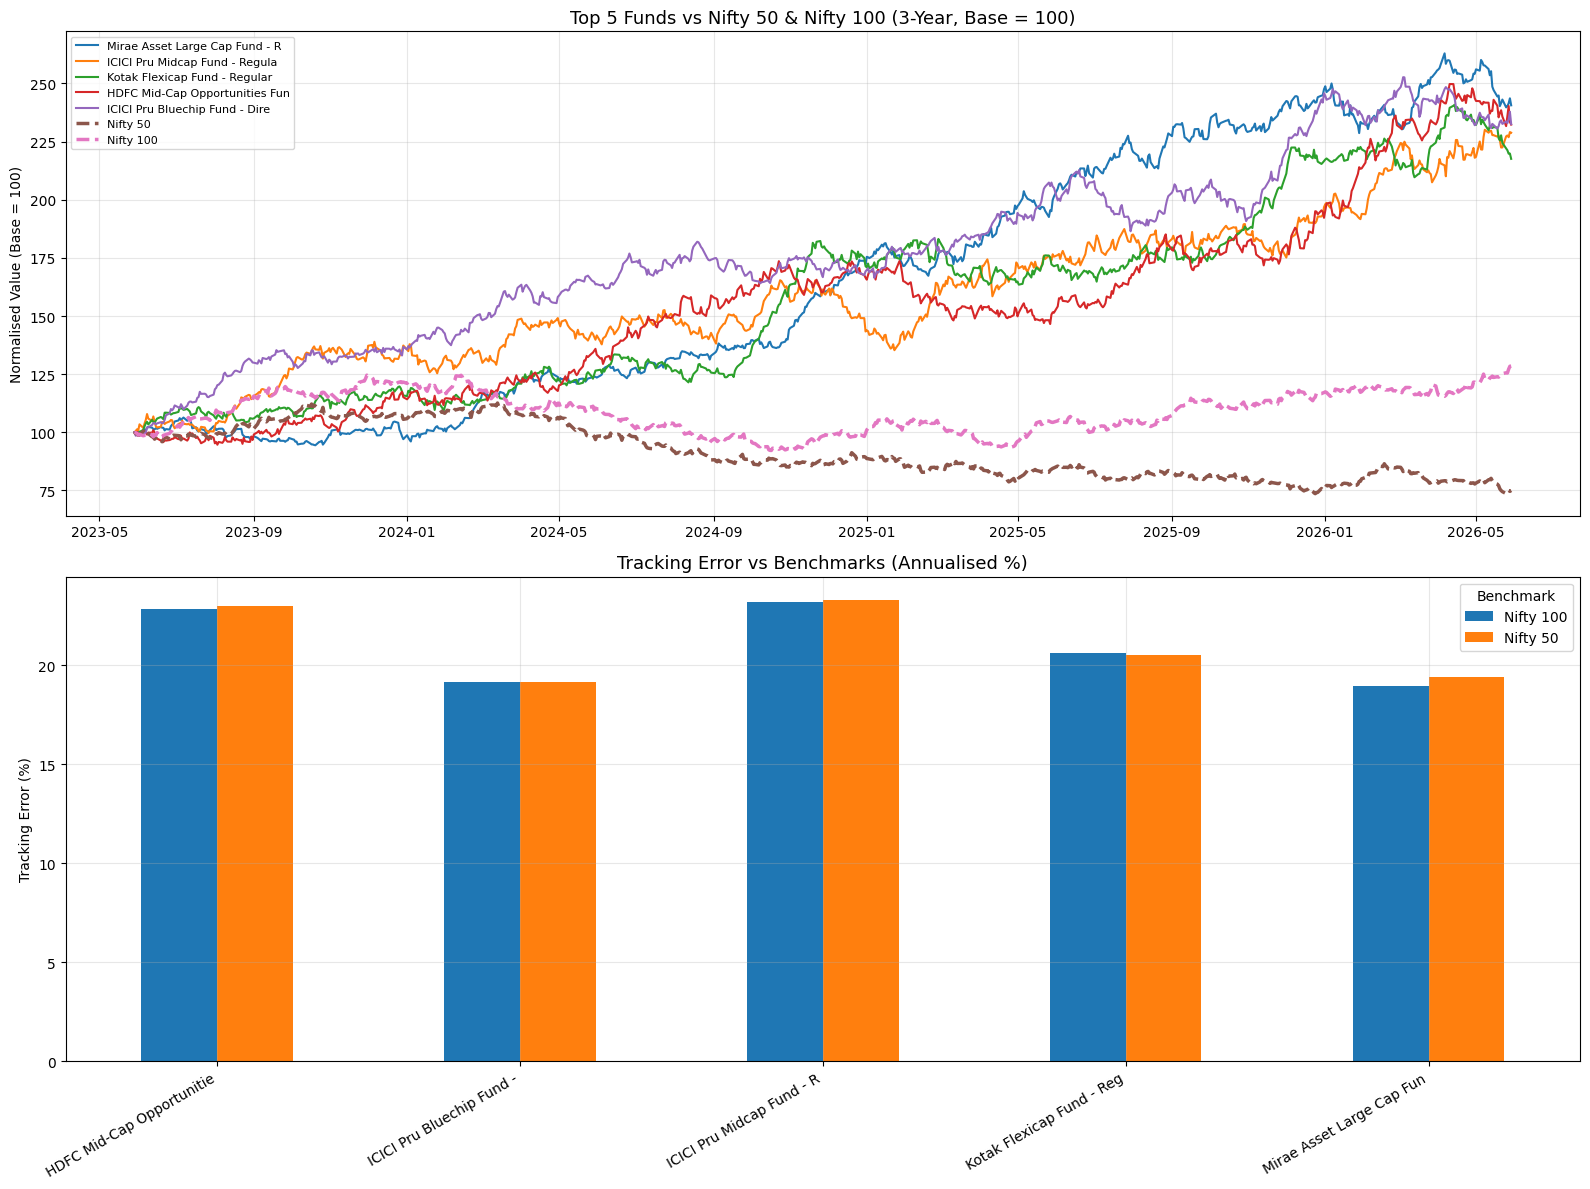

✅ Benchmark comparison chart saved
✅ Tracking error table saved


In [12]:
# Benchmark Comparison: Top 5 Funds vs NIFTY50 & NIFTY100

# Top 5 funds from scorecard
top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = (
    scorecard
    .head(5)
    .set_index("amfi_code")["scheme_name"]
    .to_dict()
)

# 3-year window
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

# Ensure datetime format
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])
daily_returns.index = pd.to_datetime(daily_returns.index)

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# CHART 1: Normalised Performance Comparison

ax = axes[0]

# Plot top 5 funds
for code in top5_codes:

    fund_nav = nav[
        (nav["amfi_code"] == code) &
        (nav["date"] >= start_date)
    ]

    if fund_nav.empty:
        continue

    fund_nav = (
        fund_nav
        .sort_values("date")
        .set_index("date")["nav"]
    )

    normalised = fund_nav / fund_nav.iloc[0] * 100

    ax.plot(
        normalised.index,
        normalised.values,
        label=top5_names[code][:30],
        linewidth=1.5
    )

# Plot benchmarks
for idx_name in ["NIFTY50", "NIFTY100"]:

    idx_data = benchmark[
        (benchmark["index_name"] == idx_name) &
        (benchmark["date"] >= start_date)
    ]

    if idx_data.empty:
        continue

    idx_data = (
        idx_data
        .sort_values("date")
        .drop_duplicates(subset=["date"])
        .set_index("date")["close_value"]
    )

    normalised = idx_data / idx_data.iloc[0] * 100

    display_name = (
        "Nifty 50"
        if idx_name == "NIFTY50"
        else "Nifty 100"
    )

    ax.plot(
        normalised.index,
        normalised.values,
        linewidth=2.5,
        linestyle="--",
        label=display_name
    )

ax.set_title(
    "Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year, Base = 100)",
    fontsize=13
)

ax.set_ylabel("Normalised Value (Base = 100)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# CHART 2: Tracking Error

ax2 = axes[1]

te_data = []

for code in top5_codes:

    fund_ret = daily_returns[code].dropna()

    for idx_name in ["NIFTY50", "NIFTY100"]:

        idx_ret = benchmark[
            benchmark["index_name"] == idx_name
        ].copy()

        if idx_ret.empty:
            continue

        idx_ret["date"] = pd.to_datetime(idx_ret["date"])

        idx_ret = (
            idx_ret
            .sort_values("date")
            .drop_duplicates(subset=["date"])
            .set_index("date")["close_value"]
            .pct_change()
            .dropna()
        )

        aligned = pd.concat(
            [fund_ret, idx_ret],
            axis=1,
            join="inner"
        ).dropna()

        if len(aligned) < 30:
            continue

        aligned.columns = ["fund", "benchmark"]

        tracking_error = (
            (aligned["fund"] - aligned["benchmark"])
            .std()
            * np.sqrt(252)
            * 100
        )

        te_data.append({
            "fund": top5_names[code][:25],
            "benchmark":
                "Nifty 50"
                if idx_name == "NIFTY50"
                else "Nifty 100",
            "tracking_error": round(tracking_error, 2)
        })

# Create TE dataframe
te_df = pd.DataFrame(te_data)

if not te_df.empty:

    te_pivot = te_df.pivot(
        index="fund",
        columns="benchmark",
        values="tracking_error"
    )

    te_pivot.plot(
        kind="bar",
        ax=ax2
    )

    ax2.set_title(
        "Tracking Error vs Benchmarks (Annualised %)",
        fontsize=13
    )

    ax2.set_ylabel("Tracking Error (%)")
    ax2.set_xlabel("")
    ax2.legend(title="Benchmark")

    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=30,
        ha="right"
    )

else:
    ax2.text(
        0.5,
        0.5,
        "No Tracking Error Data Available",
        ha="center",
        va="center",
        transform=ax2.transAxes
    )

ax2.grid(True, alpha=0.3)

# Save Output

plt.tight_layout()

plt.savefig(
    f"{CHARTS}/11_benchmark_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Benchmark comparison chart saved")

# Optional: save tracking error table
te_df.to_csv(
    f"{OUTPUT}/tracking_error.csv",
    index=False
)

print("✅ Tracking error table saved")

In [16]:
print("=" * 60)
print("DAY 4 DELIVERABLES SUMMARY")
print("=" * 60)
print(f"✅ Daily returns computed for {daily_returns.shape[1]} funds")
print(f"✅ CAGR table: {cagr_df.shape[0]} funds")
print(f"✅ Sharpe Ratio: top fund = {sharpe_df.iloc[0]['scheme_name'][:40]}")
print(f"✅ Sortino Ratio: top fund = {sortino_df.iloc[0]['scheme_name'][:40]}")
print(f"✅ Alpha/Beta saved → alpha_beta.csv")
print(f"✅ Max Drawdown: worst = {drawdown_df.iloc[0]['scheme_name'][:40]} ({drawdown_df.iloc[0]['max_drawdown']}%)")
print(f"✅ Fund Scorecard saved → fund_scorecard.csv")
print(f"✅ Benchmark chart saved → reports/charts/11_benchmark_comparison.png")
print("\nTop 5 Funds by Scorecard:")
print(scorecard[["scheme_name","score"]].head(5).to_string())

DAY 4 DELIVERABLES SUMMARY
✅ Daily returns computed for 40 funds
✅ CAGR table: 40 funds
✅ Sharpe Ratio: top fund = Mirae Asset Large Cap Fund - Regular - G
✅ Sortino Ratio: top fund = Mirae Asset Large Cap Fund - Regular - G
✅ Alpha/Beta saved → alpha_beta.csv
✅ Max Drawdown: worst = SBI Small Cap Fund - Direct Plan - Growt (-52.57%)
✅ Fund Scorecard saved → fund_scorecard.csv
✅ Benchmark chart saved → reports/charts/11_benchmark_comparison.png

Top 5 Funds by Scorecard:
                                          scheme_name  score
1       Mirae Asset Large Cap Fund - Regular - Growth  88.86
2           ICICI Pru Bluechip Fund - Direct - Growth  82.00
3            ICICI Pru Midcap Fund - Regular - Growth  78.14
4  HDFC Mid-Cap Opportunities Fund - Regular - Growth  77.10
5           SBI Bluechip Fund - Regular Plan - Growth  77.10
